# Occupation erasure via top-k selection

Erase **occupation** from off-the-shelf embeddings using **top-k greedy question selection**:
an LLM expands the concept into a pool of yes/no questions, JEV scores them, and `select_k` greedily
keeps the few that best reconstruct the pool. We then erase with just those and measure held-out
**occupation** accuracy before vs. after.

Runs offline from the bundled cache (`USE_CACHE=True`); set it `False` to call the APIs live.

In [1]:
import os, sys, json, hashlib, logging
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
for _n in ('httpx', 'httpcore', 'openai', 'openai._base_client'):
    logging.getLogger(_n).setLevel(logging.WARNING)       # silence OpenAI/OpenRouter request logs

def _root(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q/'pyproject.toml').exists() and (q/'src'/'jevu').exists():
            return q
    return Path(s).resolve()
ROOT = _root(os.getcwd())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from jevu import ConceptScrubber

_envf = ROOT/'.env'
if _envf.exists():
    for _l in _envf.read_text().splitlines():
        _l = _l.strip()
        if _l and not _l.startswith('#') and '=' in _l:
            _k, _v = _l.split('=', 1); os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

USE_CACHE = True        # offline from the bundled cache; set False to call APIs live
CACHE = (ROOT/'examples'/'.jev_debias_cache') if USE_CACHE else None
if CACHE: CACHE.mkdir(parents=True, exist_ok=True)
SEED, N, DENSE_MODEL = 2026, 900, 'text-embedding-3-small'
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
def dg(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def sj(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('caching:', bool(CACHE))

caching: True


## 1. Data: real bios + off-the-shelf embeddings

In [2]:
def hf_page(off, length=100):
    p = (CACHE/f'bios_{SPLIT}_{off}_{length}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())
    import httpx
    r = httpx.get(HF_ROWS, params={'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(off), 'length': int(length)}, timeout=60); r.raise_for_status()
    d = r.json();
    if p: sj(p, d)
    return d

def load_bios(n, seed):
    p = (CACHE/f'bios_sample_{n}_{seed}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']; rng = np.random.default_rng(seed)
    rows = []
    for off in rng.permutation(np.arange(0, total, 100)):
        for it in hf_page(int(off), 100)['rows']:
            r = it['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]
    if p: sj(p, {'rows': rows})
    return rows

def embed_dense(texts):
    p = (CACHE/f'dense_{dg({"m": DENSE_MODEL, "t": texts})}.json') if CACHE else None
    if p and p.exists(): return np.asarray(json.loads(p.read_text()), dtype=float)
    from openai import OpenAI
    cl = OpenAI(timeout=90); v = []
    for s in range(0, len(texts), 200):
        v.extend(x.embedding for x in cl.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(v, dtype=float)
    if p: sj(p, v.tolist())
    return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows]); gender = np.array([r['gender'] for r in rows])
X = normalize(embed_dense(texts))
tr, te = train_test_split(np.arange(N), test_size=0.3, random_state=SEED, stratify=gender)
print(len(texts), 'bios |', len(np.unique(prof)), 'occupations | embeddings', X.shape)

900 bios | 28 occupations | embeddings (900, 1536)


## 2. Erase occupation with top-k selected questions

Pool of **15** questions; sweep `select_k` to see how few questions you need. The greedy picks are logged (`INFO jevu.scrubber: greedy select …`) and stored in `selected_questions_`.

Selection runs on a **250-row sample** (`select_sample=250`): the pool is scored only on the sample, then just the kept questions are scored on the full train split.

In [3]:
CONCEPT = 'the specific profession or occupation the person has'
def acc(A, B): return accuracy_score(prof[te], LogisticRegression(max_iter=3000).fit(A, prof[tr]).predict(B))
print('raw occupation acc:', round(acc(X[tr], X[te]), 3))
print('\n--- select_k sweep (greedy from a 15-question pool) ---')
for k in [1, 3, 6, 15]:
    scr = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                          select_k=(None if k == 15 else k), select_sample=250,
                          cache_dir=str(CACHE) if CACHE else None)
    scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr])
    Xd = scr.transform(X)
    kept = scr.selected_questions_ if k != 15 else '(all 15)'
    print(f'  k={k:<2} occupation acc {acc(Xd[tr], Xd[te]):.3f}')
    if k != 15:
        for q in scr.selected_questions_: print('        -', q)

INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text mention a healthcare professional?', 'Does the text refer to someone in education or academia?', 'Does the text describe a legal professional?', 'Does the text indicate an artist or performer?', 'Does the text mention a writer or author?', 'Does the text identify someone as a researcher or scholar?', 'Does the text refer to a journalist or media professional?', 'Does the text describe a scientist or engineer?', 'Does the text mention an individual involved in community service or advocacy?', 'Does the text indicate a person working in the field of technology?', 'Does the text refer to someone in the performing arts?', 'Does the text describe a business or finance professional?', 'Does the text mention an individual in the field of social work?', 'Does the text indicate a person involved in public service or government?', 'Does the text describe someone working 

INFO jevu.scrubber: selecting 1/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (3750 cached, 0 to fetch)


raw occupation acc: 0.648

--- select_k sweep (greedy from a 15-question pool) ---


JEV x15: the specific profession or occ:   0%|          | 0/3750 [00:00<?, ?it/s]

...

INFO jevu.concepts: scoring 630 texts x 15 questions = 9450 cells (9450 cached, 0 to fetch)


  k=6  occupation acc 0.367
        - Does the text identify someone as a researcher or scholar?
        - Does the text mention a healthcare professional?
        - Does the text indicate an artist or performer?
        - Does the text mention a writer or author?
        - Does the text mention an individual involved in community service or advocacy?
        - Does the text indicate a person working in the field of technology?


JEV x15: the specific profession or occ:   0%|          | 0/9450 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=15)


  k=15 occupation acc 0.322


## 3. PCA: embeddings before vs. after erasure

Same 2-D PCA axes for both panels (fit on the originals). Colored by the top occupations: the clusters that separate professions **before** collapse/merge **after** erasing occupation.

INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text mention a healthcare professional?', 'Does the text refer to someone in education or academia?', 'Does the text describe a legal professional?', 'Does the text indicate an artist or performer?', 'Does the text mention a writer or author?', 'Does the text identify someone as a researcher or scholar?', 'Does the text refer to a journalist or media professional?', 'Does the text describe a scientist or engineer?', 'Does the text mention an individual involved in community service or advocacy?', 'Does the text indicate a person working in the field of technology?', 'Does the text refer to someone in the performing arts?', 'Does the text describe a business or finance professional?', 'Does the text mention an individual in the field of social work?', 'Does the text indicate a person involved in public service or government?', 'Does the text describe someone working 

INFO jevu.scrubber: selecting 3/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (3750 cached, 0 to fetch)


JEV x15: the specific profession or occ:   0%|          | 0/3750 [00:00<?, ?it/s]

INFO jevu.scrubber: greedy select 1/3: 'Does the text identify someone as a researcher or scholar?' (reconstruction residual 15.328)


...

INFO jevu.scrubber: greedy select 3/3: 'Does the text indicate an artist or performer?' (reconstruction residual 12.080)


INFO jevu.scrubber: kept 3/15 questions: ['Does the text identify someone as a researcher or scholar?', 'Does the text mention a healthcare professional?', 'Does the text indicate an artist or performer?']


INFO jevu.concepts: scoring 630 texts x 3 questions = 1890 cells (1890 cached, 0 to fetch)


JEV x3: the specific profession or occ:   0%|          | 0/1890 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=3)


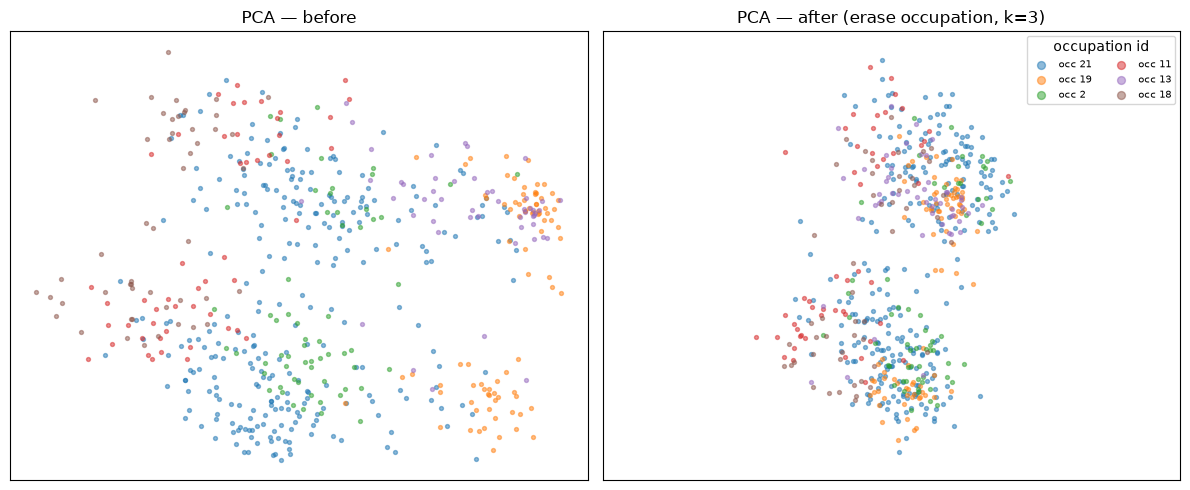

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
scr_v = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                        select_k=3, select_sample=250, cache_dir=str(CACHE) if CACHE else None)
scr_v.fit(embeddings=X[tr], texts=[texts[i] for i in tr]); Xd = scr_v.transform(X)
pca = PCA(n_components=2, random_state=SEED).fit(X)
PB, PA = pca.transform(X), pca.transform(Xd)
vals, counts = np.unique(prof, return_counts=True); top = vals[np.argsort(-counts)[:6]]
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for axi, (P, ttl) in zip(ax, [(PB, 'before'), (PA, 'after (erase occupation, k=3)')]):
    for t in top:
        m = prof == t; axi.scatter(P[m, 0], P[m, 1], s=8, alpha=0.5, label=f'occ {t}')
    axi.set_title(f'PCA — {ttl}'); axi.set_xticks([]); axi.set_yticks([])
ax[1].legend(fontsize=7, ncol=2, markerscale=2, title='occupation id')
plt.tight_layout(); plt.show()

## 4. Reading it

More selected questions → more of the concept removed → lower occupation accuracy. A binary concept needs ~1 question; a many-valued identity needs a small covering set. The chosen questions are reusable: deploy just those few to scrub new embeddings cheaply.